### Bloque 1: Introducción y Exploración de Datos Crudos

En este proyecto voy a analizar el proteoma de la *Escherichia coli* (cepa K-12 MG1655), que es uno de los organismos modelo más estudiados en biología. 

Para esto, descargué las secuencias de sus proteínas desde la base de datos del NCBI. Los datos originales vienen en **formato FASTA**, que es el estándar universal en bioinformática: un archivo de texto plano donde cada proteína está compuesta por un encabezado (que siempre arranca con el símbolo `>`) y, debajo, la secuencia de aminoácidos dividida en varios renglones.

Como primer paso, voy a abrir el archivo crudo e imprimir solo las primeras 10 líneas. Esto me sirve para entender visualmente la estructura del texto antes de empezar a programar la lógica para extraer y ordenar los datos.

In [48]:
with open("../data/raw/sequence.fasta", "r") as archivo:
    
    # Crea un contador para saber en qué línea esta
    contador_lineas = 0
    
    # Recorre el archivo renglón por renglón
    for linea in archivo:
        print(linea.strip()) # .strip() limpia los saltos de línea invisibles
        
        # Suma 1 al contador
        contador_lineas += 1
        
        # Si llega a la línea 10, frena el ciclo para no imprimir todo
        if contador_lineas == 10:
            break

>NP_416451.1 flagellar export ATPase FliI [Escherichia coli str. K-12 substr. MG1655]
MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQLPLGATCVIERQNGSETHEVESEVV
GFNGQRLFLMPLEEVEGVLPGARVYAKNISAEGLQSGKQLPLGPALLGRVLDGSGKPLDGLPSPDTTETG
ALITPPFNPLQRTPIEHVLDTGVRPINALLTVGRGQRMGLFAGSGVGKSVLLGMMARYTRADVIVVGLIG
ERGREVKDFIENILGAEGRARSVVIAAPADVSPLLRMQGAAYATRIAEDFRDRGQHVLLIMDSLTRYAMA
QREIALAIGEPPATKGYPPSVFAKLPALVERAGNGISGGGSITAFYTVLTEGDDQQDPIADSARAILDGH
IVLSRRLAEAGHYPAIDIEASISRAMTALISEQHYARVRTFKQLLSSFQRNRDLVSVGAYAKGSDPMLDK
AIALWPQLEGYLQQGIFERADWEASLQGLERIFPTVS

>NP_416437.1 alpha-amylase [Escherichia coli str. K-12 substr. MG1655]


### Bloque 2: Extracción y Estructuración Manual
En este bloque voy a procesar (o *parsear*) el texto crudo para separar de forma estructurada los identificadores (IDs) de las secuencias de aminoácidos correspondientes.

In [49]:
dicc = {}
id_actual = ""

with open("../data/raw/sequence.fasta", "r") as archivo:
    for linea in archivo:
        if linea.startswith(">"):
            # Extrae el ID: omite el '>' y guarda solo la primera palabra
            id = linea[1:].split()[0]
            id_actual = id
            dicc[id] = "" # Inicia la secuencia vacía para este ID
        else:
            # Limpia el salto de línea y concatena el fragmento a la secuencia principal
            linea_limpia = linea.strip()
            dicc[id_actual] += linea_limpia

# Test: muestra las primeras 3 proteínas extraídas (ID y su secuencia)
for id_test in list(dicc.keys())[:3]:
    print(f"ID: {id_test}")
    print(f"Secuencia (primeros 50 aa): {dicc[id_test][:50]}...")

print("-" * 30)

# Test: cuenta el total de secuencias extraidas
print(f"Total de secuencias extraídas: {len(dicc)}")

ID: NP_416451.1
Secuencia (primeros 50 aa): MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQLPLGA...
ID: NP_416437.1
Secuencia (primeros 50 aa): MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYKGASG...
ID: NP_416438.1
Secuencia (primeros 50 aa): MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRALVSP...
------------------------------
Total de secuencias extraídas: 4300


### Bloque 3: Estructuración en Pandas (DataFrame)

Si bien tengo la información estructurada en un diccionario de Python, para realizar un análisis estadístico y profesional es necesario generar la estructura de tabla. Para eso, voy a utilizar la librería Pandas y así obtener un DataFrame.

In [ ]:
import pandas as pd

# Convierte los items del diccionario directamente a columnas
df = pd.DataFrame(list(dicc.items()), columns=['id', 'secuencia'])

# Test: comprueba que estén las 4300 secuencias 
print(f"Filas totales del Dataframe: {len(df)}")
# Test: muestra las primeras filas del Dataframe
df.head()

Filas totales del Dataframe: 4300


,id,secuencia
0,NP_416451.1,MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQL...
1,NP_416437.1,MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYK...
2,NP_416438.1,MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRA...
3,NP_416439.1,MSWQQFKHAWLIKFWAPIPAVIAAGILSTYYFGITGTFWAVTGEFT...
4,NP_416440.1,MKNIVPDYRLDMVGEPCPYPAVATLEAMPQLKKGEILEVVSDCPQS...


### Bloque 4: Ingeniería de Características (Feature Engineering)
Al ser secuencias de texto puro no se pueden graficar fácilmente. Por ende, hay que extraer métricas cuantitativas. 

A continuación voy a calcular: **La LONGITUD y la FRECUENCIA de aminoácidos**.

Nota: Voy a descartar el cálculo del contenido %GC ya que el archivo contiene Proteínas (compuestas por aminoácidos) y el %GC es una métrica exclusiva de ácidos nucleicos (ADN/ARN).

##### Voy a crear una columna llamada 'longitud' que detalla la cantidad de aminoácidos de cada secuencia.

In [80]:
df['longitud'] = df['secuencia'].str.len()
df.head()

,id,secuencia,longitud,frecuencia_aa
0,NP_416451.1,MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQL...,457,"{'M': 11, 'T': 27, 'R': 37, 'L': 54, 'W': 3, '..."
1,NP_416437.1,MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYK...,495,"{'M': 11, 'R': 20, 'N': 21, 'P': 23, 'T': 22, ..."
2,NP_416438.1,MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRA...,137,"{'M': 4, 'K': 8, 'L': 16, 'A': 15, 'I': 5, 'G'..."
3,NP_416439.1,MSWQQFKHAWLIKFWAPIPAVIAAGILSTYYFGITGTFWAVTGEFT...,401,"{'M': 19, 'S': 12, 'W': 18, 'Q': 14, 'F': 33, ..."
4,NP_416440.1,MKNIVPDYRLDMVGEPCPYPAVATLEAMPQLKKGEILEVVSDCPQS...,77,"{'M': 3, 'K': 4, 'N': 4, 'I': 7, 'V': 6, 'P': ..."


##### Voy a crear una columna para la frecuencia de cada aminoácido (aa) en cada secuencia (proteína).

In [81]:
def contar_letras (seq: str):
    dicc = {}
    for letra in seq:
        if letra not in dicc:
            dicc[letra] = 1
        else:
            dicc[letra] += 1
    return dicc

df['frecuencia_aa'] = df['secuencia'].apply(contar_letras)
df.head()

,id,secuencia,longitud,frecuencia_aa
0,NP_416451.1,MTTRLTRWLTTLDNFEAKMAQLPAVRRYGRLTRATGLVLEATGLQL...,457,"{'M': 11, 'T': 27, 'R': 37, 'L': 54, 'W': 3, '..."
1,NP_416437.1,MRNPTLLQCFHWYYPEGGKLWPELAERADGFNDIGINMVWLPPAYK...,495,"{'M': 11, 'R': 20, 'N': 21, 'P': 23, 'T': 22, ..."
2,NP_416438.1,MKKLAIAGALLLLAGCAEVENYNNVVKTPAPDWLAGYWQTKGPQRA...,137,"{'M': 4, 'K': 8, 'L': 16, 'A': 15, 'I': 5, 'G'..."
3,NP_416439.1,MSWQQFKHAWLIKFWAPIPAVIAAGILSTYYFGITGTFWAVTGEFT...,401,"{'M': 19, 'S': 12, 'W': 18, 'Q': 14, 'F': 33, ..."
4,NP_416440.1,MKNIVPDYRLDMVGEPCPYPAVATLEAMPQLKKGEILEVVSDCPQS...,77,"{'M': 3, 'K': 4, 'N': 4, 'I': 7, 'V': 6, 'P': ..."


### Bloque 5: Análisis Exploratorio Visual (EDA)

Con el dataset limpio y las métricas calculadas, pasamos a la parte donde los números se transforman en insights: el análisis exploratorio visual (EDA). Leer las filas y columnas nos sirve para arrancar, pero en bioinformática, la estrategia de supervivencia de una bacteria se entiende de verdad cuando empezamos a graficar los datos.

Para este análisis, voy a armar dos visualizaciones principales:

1. **Distribución de las longitudes:** Mediante un histograma, la idea es observar el tamaño promedio de las proteínas que sintetiza la *E. coli*. Esto nos va a mostrar gráficamente si la bacteria prioriza la eficiencia armando cadenas cortas, o si invierte en macromoléculas gigantes.
2. **Frecuencia global de aminoácidos:** El objetivo acá es unificar todos los conteos individuales para observar el panorama general del genoma. Queremos descubrir cuáles son los aminoácidos que más usa la bacteria para construirse y cuáles son los más escasos/raros (biológicamente suele estar ligado a la complejidad de la molécula y al costo energético que le requiere fabricarlos).

Importo las librerias matplotlib (pyplot) y seaborn para realizar los gráficos.

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

##### Gráfico 1: Distribución de Longitudes


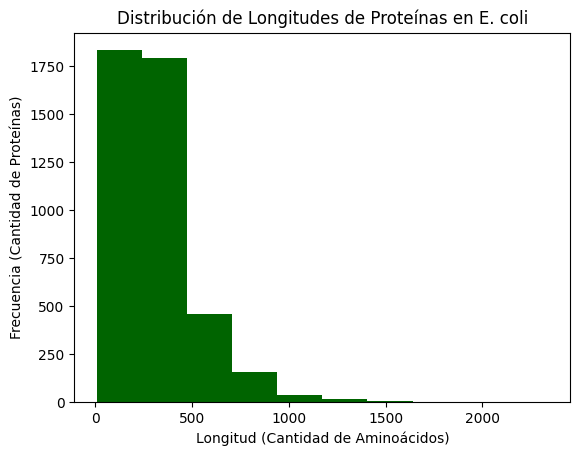

In [ ]:
df['longitud'].hist(grid= False, color='darkgreen')
# 2. Agrega las etiquetas de texto
plt.title("Distribución de Longitudes de Proteínas en E. coli")
plt.xlabel("Longitud (Cantidad de Aminoácidos)")
plt.ylabel("Frecuencia (Cantidad de Proteínas)")
plt.show()

**Conclusión de la Distribución de Longitudes:**

Al analizar el histograma, lo primero que se observa es una clarísima distribución asimétrica positiva (lo que estadísticamente llamamos sesgo a la derecha). La inmensa mayoría de las proteínas de la *E. coli* se agrupan en un rango pequeño, de entre 0 a 500 aminoácidos aproximadamente.

Desde el punto de vista biológico, esto corresponde a un principio de supervivencia. La bacteria compite por dividirse y reproducirse lo más rápido posible, y fabricar proteínas es uno de los procesos que más energía (ATP) consume. Al priorizar la síntesis de proteínas cortas, la célula ahorra tiempo y recursos valiosos.

Por otro lado, esa "cola" que se estira hacia la derecha muestra casos muy puntuales de proteínas gigantes que llegan a los 1500/2000 aminoácidos. Estos casos atípicos (outliers) son pocos porque representan maquinarias moleculares sumamente complejas que la bacteria solo fabrica cuando necesita funciones estructurales muy específicas. Básicamente, el gráfico nos muestra una bacteria que "elige" ser pequeña y eficiente para reproducirse lo más rápido posible.

Gráfico 2: Frecuencia global de aminoácidos

In [ ]:
# Suma todos los diccionarios individuales de la tabla en un único diccionario general
dicc_grande = {}

for dicc_chico in df['frecuencia_aa']: 
    for letra, cantidad in dicc_chico.items():
        if letra not in dicc_grande:
            dicc_grande[letra] = cantidad
        else:
            dicc_grande[letra] += cantidad

print(dicc_grande)

{'M': 37659, 'T': 71428, 'R': 73626, 'L': 142387, 'W': 20299, 'D': 68217, 'N': 51897, 'F': 51802, 'E': 76888, 'A': 126896, 'K': 58576, 'Q': 59178, 'P': 59036, 'V': 94241, 'Y': 37630, 'G': 97833, 'C': 15470, 'I': 79953, 'S': 76872, 'H': 30145, 'U': 3}


In [ ]:
# Transforma el diccionario a DataFrame y lo ordena de mayor a menor para el gráfico
df_2 = pd.DataFrame(list(dicc_grande.items()), columns=['letra', 'cantidad'])
df_2 = df_2.sort_values(by= 'cantidad', ascending= False)
print(df_2)

   letra  cantidad
3      L    142387
9      A    126896
15     G     97833
13     V     94241
17     I     79953
8      E     76888
18     S     76872
2      R     73626
1      T     71428
5      D     68217
11     Q     59178
12     P     59036
10     K     58576
6      N     51897
7      F     51802
0      M     37659
14     Y     37630
19     H     30145
4      W     20299
16     C     15470
20     U         3


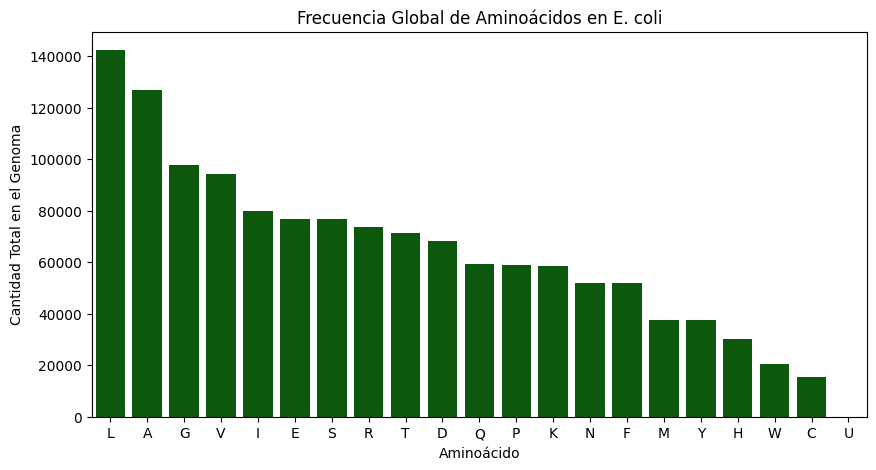

In [79]:
# Configura el tamaño de la figura y dibuja el gráfico de barras con Seaborn
plt.figure(figsize=(10, 5))
sns.barplot(data=df_2, x='letra', y='cantidad', color='darkgreen')

# Agrega las etiquetas  y muestra el gráfico
plt.title("Frecuencia Global de Aminoácidos en E. coli")
plt.xlabel("Aminoácido")
plt.ylabel("Cantidad Total en el Genoma")
plt.show()

**Conclusión de la Frecuencia de Aminoácidos:**

Al analizar este gráfico, lo primero que se observa es que la *E. coli* tiene una preferencia muy marcada por ciertos aminoácidos a la hora de construir sus proteínas. Hay un contraste enorme: la Leucina (L) y la Alanina (A) son, por lejos, los más usados en todo su genoma. En cambio, si miramos el final del gráfico, vemos que el Triptófano (W) y la Cisteína (C) aparecen en cantidades bajísimas. 

Desde el punto de vista biológico, esto cierra perfecto con la idea de optimizar recursos. Cada aminoácido tiene un costo de "fabricación" distinto. La A y la L tienen estructuras moleculares súper simples, por ende a la célula le cuesta muy poca energía (ATP) producirlos. Por el otro lado, para armar Triptófano hay que construir anillos moleculares complejos, y para la Cisteína hace falta incorporar azufre; todo eso exige más pasos químicos y un gasto altísimo de energía.

Básicamente, la bacteria busca ser lo más eficiente posible. Para sostener su ritmo acelerado de reproducción, arma la mayor parte de sus estructuras usando los aminoácidos más sencillos y de bajo costo metabólico. Los aminoácidos más complejos los guarda solo para las partes de la proteína donde son estrictamente irreemplazables. Es un ejemplo buenísimo de cómo la naturaleza optimiza sus recursos para sobrevivir y multiplicarse rápido.

### Bloque 6: Validación con BioPython (Control de Calidad)

En los bloques anteriores armé la lógica de extracción (el *parseo*) desde cero. Esto es una gran práctica para manipular texto crudo, pero en la industria bioinformática existe una herramienta estándar y optimizada para esto: **BioPython**.

Para cerrar el análisis, voy a hacer un *sanity check* (una validación rápida). Voy a leer el mismo archivo FASTA usando la función `SeqIO.parse()` de BioPython y comparar los resultados contra el `DataFrame` que construí. La idea es asegurarnos de que el algoritmo manual no se salteó ninguna proteína y que no contó saltos de línea invisibles por error.

In [ ]:
from Bio import SeqIO

# Carga el archivo original usando la librería oficial
registro_bp = list(SeqIO.parse("../data/raw/sequence.fasta", "fasta"))

# Valida que no se perdió ninguna secuencia
total_manual = len(df)
total_bp = len(registro_bp)
print(f"Total secuencias -> Manual: {total_manual} | BioPython: {total_bp}")

# Valida que el parseo del texto haya sido exacto (usando el primer registro como test)
id_bp = registro_bp[0].id
len_bp = len(registro_bp[0].seq)

print(f"\nTest Metadatos (Índice 0):")
print(f"ID -> Manual: {df.loc[0, 'id']} | BioPython: {id_bp}")
print(f"Longitud -> Manual: {df.loc[0, 'longitud']} aa | BioPython: {len_bp} aa")

Total secuencias -> Manual: 4300 | BioPython: 4300

Test Metadatos (Índice 0):
ID -> Manual: NP_416451.1 | BioPython: NP_416451.1
Longitud -> Manual: 457 aa | BioPython: 457 aa


**Conclusión de la Validación:**

Como se ve en los resultados, los números dan exactos. Las 4300 secuencias están presentes y tanto los identificadores como la longitud de la cadena coinciden a la perfección. Esto confirma que el algoritmo de extracción manual que armamos al principio es totalmente robusto y estructuró los datos con la misma precisión que la librería oficial.